# Notebook 1

---

## Overview

This notebook analyzes the landfall and postlandfall of Hurricane Helene (2024). More specifically, the tropycal Python module is utilized to analyze HURDAT2 data, forecasts, and tornado data.

---

## Imports

In [10]:
# If needed, install tropycal
#!pip install tropycal

In [1]:
# Note: some of these imports are for future work and are not necessary for this current version
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.units import units
from datetime import datetime as dt, timezone, timedelta
import geopandas as gpd
import geoviews as gv
from geoviews import opts
from holoviews.element.tiles import OSM, EsriImagery
from lonboard import viz, Map, ScatterplotLayer
import tropycal.tracks as tracks
import tropycal.tornado as tornado

/home11/grad/2025/tw126577/.local/lib/python3.13/site-packages/tropycal/_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


## Obtaining HURDAT2 Data

HURDAT2 datasets are commonly used when retrieving and analyzing tropical cyclones, or in this case, hurricanes. The tropycal module has several features that make it very useful when performing analyses on tropical cyclones, which includes being able to focus on past or current storms, individual or seasonal storms, and several different meteorological variables and features.

First, we will define which ocean basin our desired tropical cyclone was in, being the North Atlantic basin for Hurricane Helene, in order to determine which HURDAT2 data file to read. 

In [2]:
# For recent storms within the past few years, make sure to set include_btk as True
basin = tracks.TrackDataset(basin='north_atlantic',source='hurdat',include_btk=True)

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (1.88 seconds)
--> Starting to read in best track data
--> Completed reading in best track data (1.58 seconds)


We can then specify which storm from the chosen HURDAT2 data file we specifically want.

In [3]:
helene = basin.get_storm(("helene",2024))
helene

<tropycal.tracks.Storm>
Storm Summary:
    Maximum Wind:      120 knots
    Minimum Pressure:  939 hPa
    Start Time:        1200 UTC 24 September 2024
    End Time:          1200 UTC 27 September 2024

Variables:
    time        (datetime) [2024-09-23 12:00:00 .... 2024-09-28 18:00:00]
    extra_obs   (int64) [0 .... 0]
    special     (str) [ .... ]
    type        (str) [DB .... LO]
    lat         (float64) [17.2 .... 37.1]
    lon         (float64) [-81.7 .... -87.0]
    vmax        (int64) [30 .... 20]
    mslp        (int64) [1004 .... 1000]
    wmo_basin   (str) [north_atlantic .... north_atlantic]

More Information:
    id:              AL092024
    operational_id:  AL092024
    name:            HELENE
    year:            2024
    season:          2024
    basin:           north_atlantic
    source_info:     NHC Hurricane Database
    source:          hurdat
    ace:             7.0
    realtime:        False
    invest:          False
    subset:          False

Not only does this function grab the data from the desired tropical cyclone, it also shows a few important descriptive statistics and details, as well as the variables of the storm.

Next, we can take the HURDAT2 data and convert it into a Pandas dataframe to be used later for other tropycal functions.

In [4]:
helene_df = helene.to_dataframe()
helene_df

,time,extra_obs,special,type,lat,lon,vmax,mslp,wmo_basin
0,2024-09-23 12:00:00,0,,DB,17.2,-81.7,30,1004,north_atlantic
1,2024-09-23 18:00:00,0,,DB,17.8,-81.9,35,1004,north_atlantic
2,2024-09-24 00:00:00,0,,DB,18.2,-82.2,35,1002,north_atlantic
3,2024-09-24 06:00:00,0,,DB,18.6,-82.8,35,1001,north_atlantic
4,2024-09-24 12:00:00,0,,TS,19.2,-83.7,40,999,north_atlantic
5,2024-09-24 18:00:00,0,,TS,19.4,-84.6,45,997,north_atlantic
6,2024-09-25 00:00:00,0,,TS,19.7,-85.2,50,990,north_atlantic
7,2024-09-25 06:00:00,0,,TS,20.3,-85.9,55,985,north_atlantic
8,2024-09-25 12:00:00,0,,HU,21.1,-86.2,65,979,north_atlantic
9,2024-09-25 18:00:00,0,,HU,22.0,-86.5,70,978,north_atlantic


Another useful function from tropycal is grabbing forecast discussions. In this case, we can use the dataframe above of Helene to know what time it made landfall to print the forecast discussion when it did so.

In [5]:
helene_forecast = helene.get_nhc_discussion(forecast=dt(2024,9,27,3,10))
print(helene_forecast['text']) # adding ['text'] makes the forecast dicussion much more legible

ZCZC MIATCDAT4 ALL
TTAA00 KNHC DDHHMM
 
Hurricane Helene Discussion Number  15
NWS National Hurricane Center Miami FL       AL092024
1100 PM EDT Thu Sep 26 2024
 
The hurricane is about to make landfall in the Florida Big Bend
region.  Timely observations from Air Force and NOAA Hurricane
Hunter aircraft showed that Helene continued to strengthen rapidly
to Category 4 status before it approached the coast, with the
central pressure falling at about 3 mb per hour since this
afternoon.  Peak 700 mb flight-level winds from the aircraft were
136 kt, corresponding to an intensity of about 120 kt, which might
be a bit conservative.  Radar and satellite images show numerous
mesocyclones rotating around the eyewall.
 
The large hurricane continues moving rapidly north-northeastward
with the latest initial motion estimated to be 015/21 kt.  A
generally northward track is expected overnight, taking the center
from southern to northern Georgia through early Friday morning.
Later on Friday and Sat

We can also plot out hurricane track forecasts, with another method of grabbing a desired forecast is by defining which discrete forecast to use instead of using datetime. We know that Forecast #15 was when Helene made landfall from the dataframe and the forecast discussion, so we can use it below.

<GeoAxes: title={'left': 'Hurricane HELENE', 'right': '140 mph • 938 hPa • Forecast #15\nForecast Issued: 0300 UTC 27 Sep 2024'}>

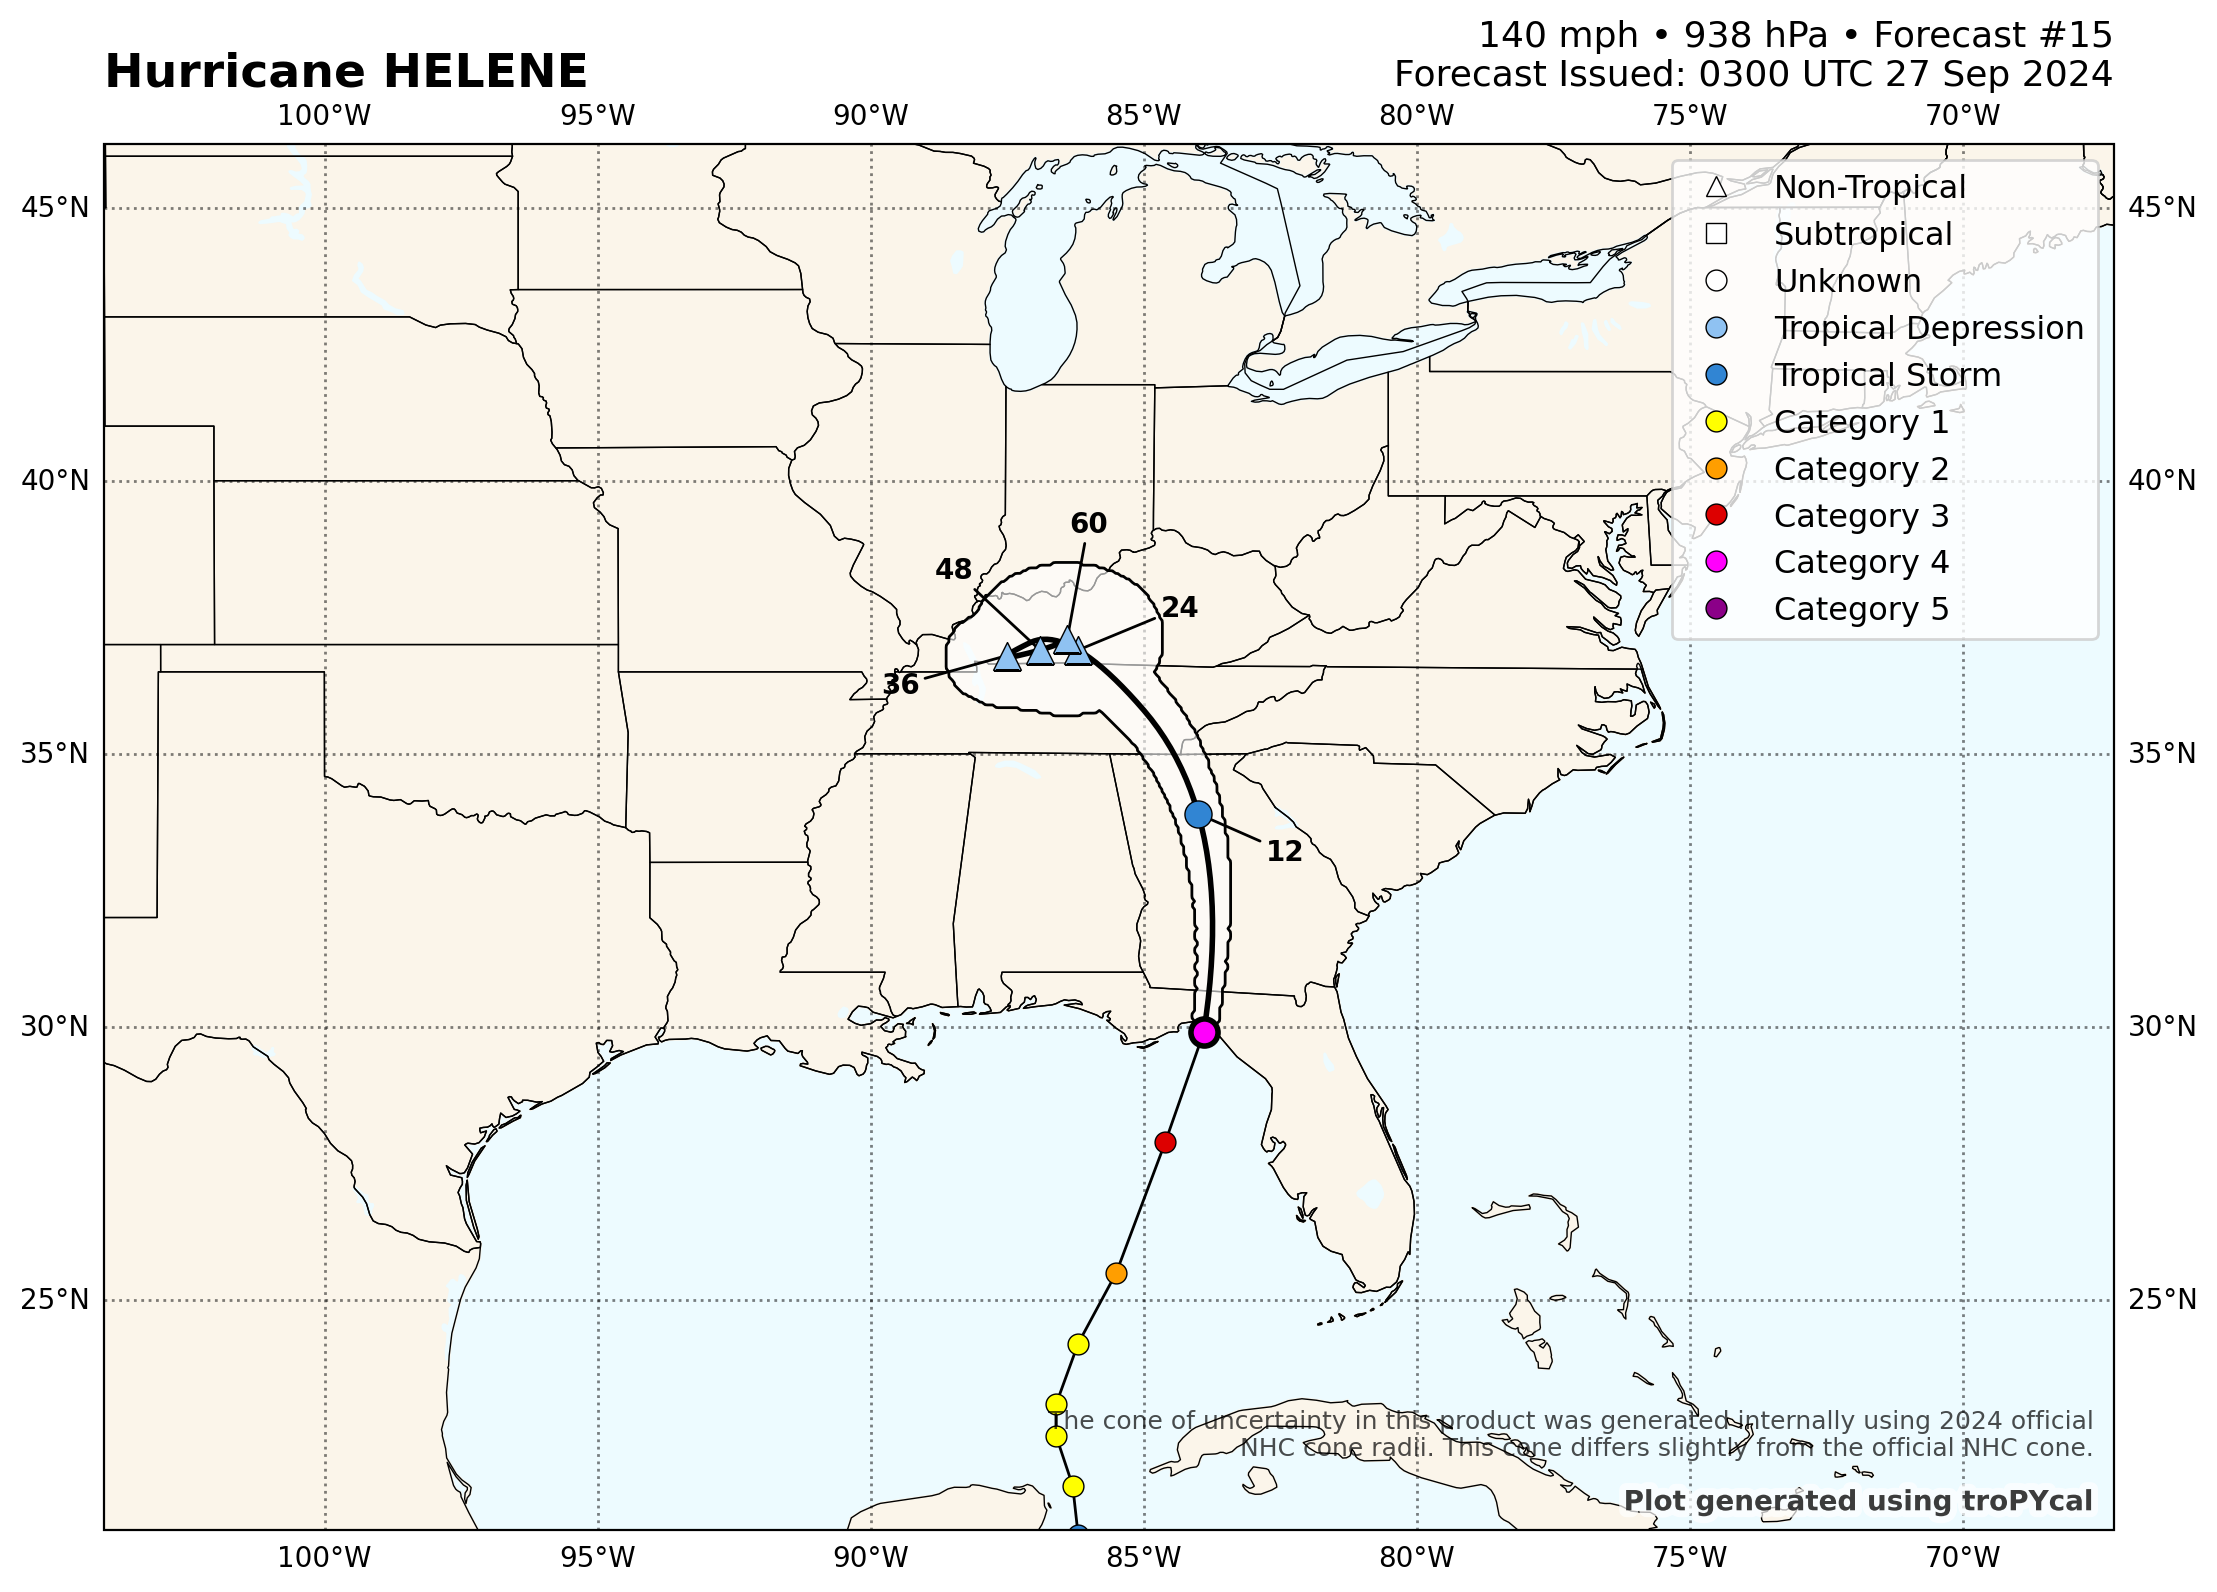

In [6]:
helene.plot_nhc_forecast(forecast=15)

## vmax & MSLP Plots

Since we specifically want to analyze Hurricane Helene during and after landfall, we can reduce the size of the dataframe to fit this timeframe.

In [7]:
helene_df_landfall = helene_df.tail(10)
helene_df_landfall

,time,extra_obs,special,type,lat,lon,vmax,mslp,wmo_basin
15,2024-09-27 03:10:00,1,L,HU,30.0,-83.7,120,939,north_atlantic
16,2024-09-27 05:00:00,1,R,HU,30.8,-83.5,95,947,north_atlantic
17,2024-09-27 06:00:00,0,,HU,31.3,-83.3,80,957,north_atlantic
18,2024-09-27 09:00:00,1,R,TS,32.9,-83.1,60,967,north_atlantic
19,2024-09-27 12:00:00,0,,TS,34.4,-83.2,45,973,north_atlantic
20,2024-09-27 18:00:00,0,,LO,36.8,-84.9,40,983,north_atlantic
21,2024-09-28 00:00:00,0,,LO,38.1,-86.6,40,985,north_atlantic
22,2024-09-28 06:00:00,0,,LO,37.4,-88.1,30,992,north_atlantic
23,2024-09-28 12:00:00,0,,LO,36.6,-87.6,25,997,north_atlantic
24,2024-09-28 18:00:00,0,,LO,37.1,-87.0,20,1000,north_atlantic


Now that we have our desired timeframe of the hurricane, we can plot out the maximum sustained wind speeds and the minimum sea-level pressure values during this time.

In [8]:
time = helene_df_landfall['time']
vmax = helene_df_landfall['vmax'] * units('kts')
mslp = helene_df_landfall['mslp'] * units('hPa')
print("Time (UTC):\n", time, "\nMax Wind Speed (kts):\n", vmax, "\nMin Sea-Level Pressure (hPa):\n", mslp)

Time (UTC):
 15   2024-09-27 03:10:00
16   2024-09-27 05:00:00
17   2024-09-27 06:00:00
18   2024-09-27 09:00:00
19   2024-09-27 12:00:00
20   2024-09-27 18:00:00
21   2024-09-28 00:00:00
22   2024-09-28 06:00:00
23   2024-09-28 12:00:00
24   2024-09-28 18:00:00
Name: time, dtype: datetime64[ns] 
Max Wind Speed (kts):
 15    120
16     95
17     80
18     60
19     45
20     40
21     40
22     30
23     25
24     20
Name: vmax, dtype: int64 
Min Sea-Level Pressure (hPa):
 15     939
16     947
17     957
18     967
19     973
20     983
21     985
22     992
23     997
24    1000
Name: mslp, dtype: int64


Text(0.5, 1.0, 'Hurricane Helene Max Wind Speed (kts) & Min Sea-Level Pressure (hPa)')

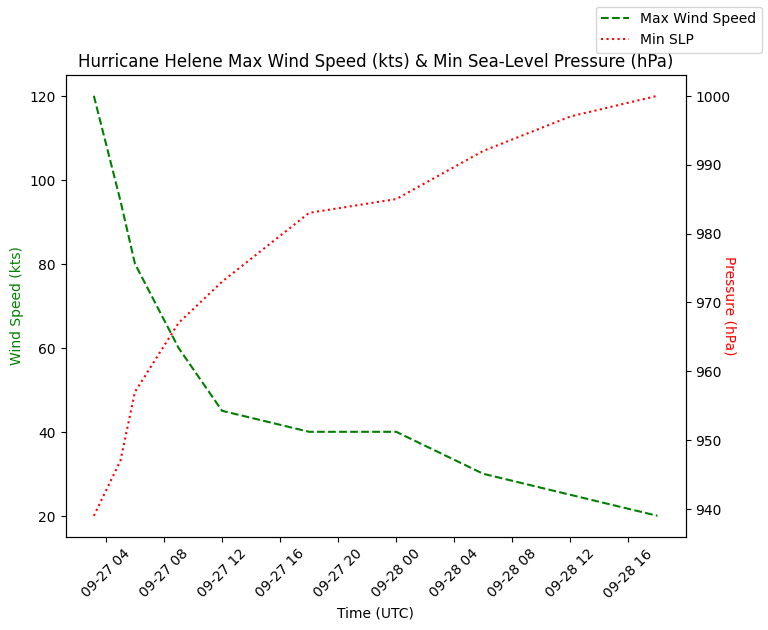

In [9]:
fig, ax1 = plt.subplots(figsize=(8,6))
ax2 = ax1.twinx()
ax1.plot(time, vmax, label="Max Wind Speed", color='green', linestyle='--')
ax2.plot(time, mslp, label="Min SLP", color='red', linestyle=':')
ax1.tick_params(axis='x', labelrotation=45)
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Wind Speed (kts)", color='green')
ax2.set_ylabel("Pressure (hPa)", color='red', rotation=270)
fig.legend()
plt.title("Hurricane Helene Max Wind Speed (kts) & Min Sea-Level Pressure (hPa)")

It can also prove to be useful to make another plot where the wind speed is in miles per hour instead of knots to make it a bit easier to interpret.

In [11]:
vmax_mph = helene_ds_landfall['vmax'] * units('kts').to('mph')
vmax_mph

Magnitude,[138.0935337628251 109.32404756223653 92.0623558418834 69.04676688141255 51.78507516105941 46.0311779209417 46.0311779209417 34.523383440706276 28.769486200588563 23.01558896047085]
Units,mile_per_hour


Text(0.5, 1.0, 'Hurricane Helene Max Wind Speed (mph) & Min Sea-Level Pressure (hPa)')

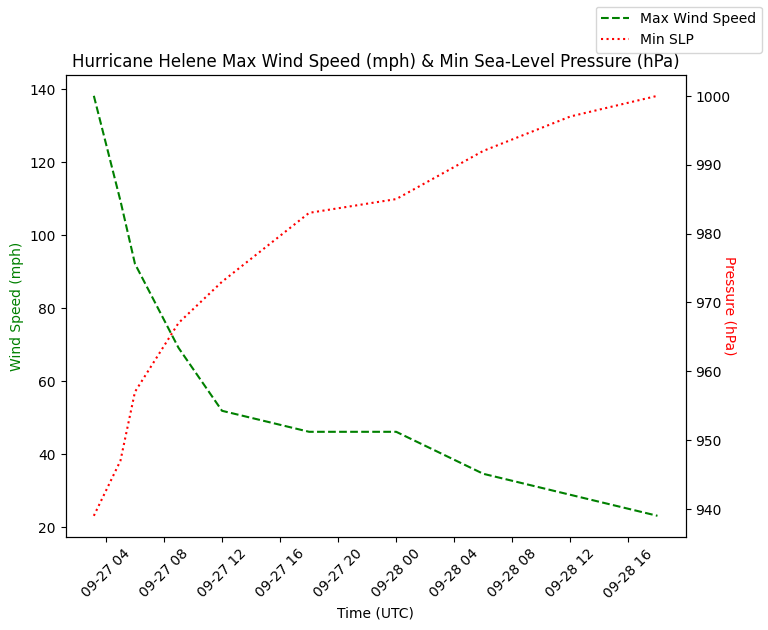

In [12]:
fig, ax1 = plt.subplots(figsize=(8,6))
ax2 = ax1.twinx()
ax1.plot(time, vmax_mph, label="Max Wind Speed", color='green', linestyle='--')
ax2.plot(time, mslp, label="Min SLP", color='red', linestyle=':')
ax1.tick_params(axis='x', labelrotation=45)
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Wind Speed (mph)", color='green')
ax2.set_ylabel("Pressure (hPa)", color='red', rotation=270)
fig.legend()
plt.title("Hurricane Helene Max Wind Speed (mph) & Min Sea-Level Pressure (hPa)")

## Tornadoes

Tropycal also has a feature that can grab tornado track data and apply said data to tropical cyclones.

In [13]:
tor_ds = tornado.TornadoDataset()

--> Starting to read in tornado track data
--> Completed reading in tornado data for 1950-2024 (1.28 seconds)


It is possible to plot a map with the hurricane track, as well as the tornado tracks and Practically Perfect Forecast (PPH).

--> Starting to read in tornado track data
--> Completed reading in tornado data for 1950-2024 (1.07 seconds)


<GeoAxes: title={'left': 'Hurricane HELENE\nTornado tracks and daily PPH (%)', 'right': '24 Sep 2024 – 27 Sep 2024\n120 kt • 939 hPa • 7.0 ACE'}>

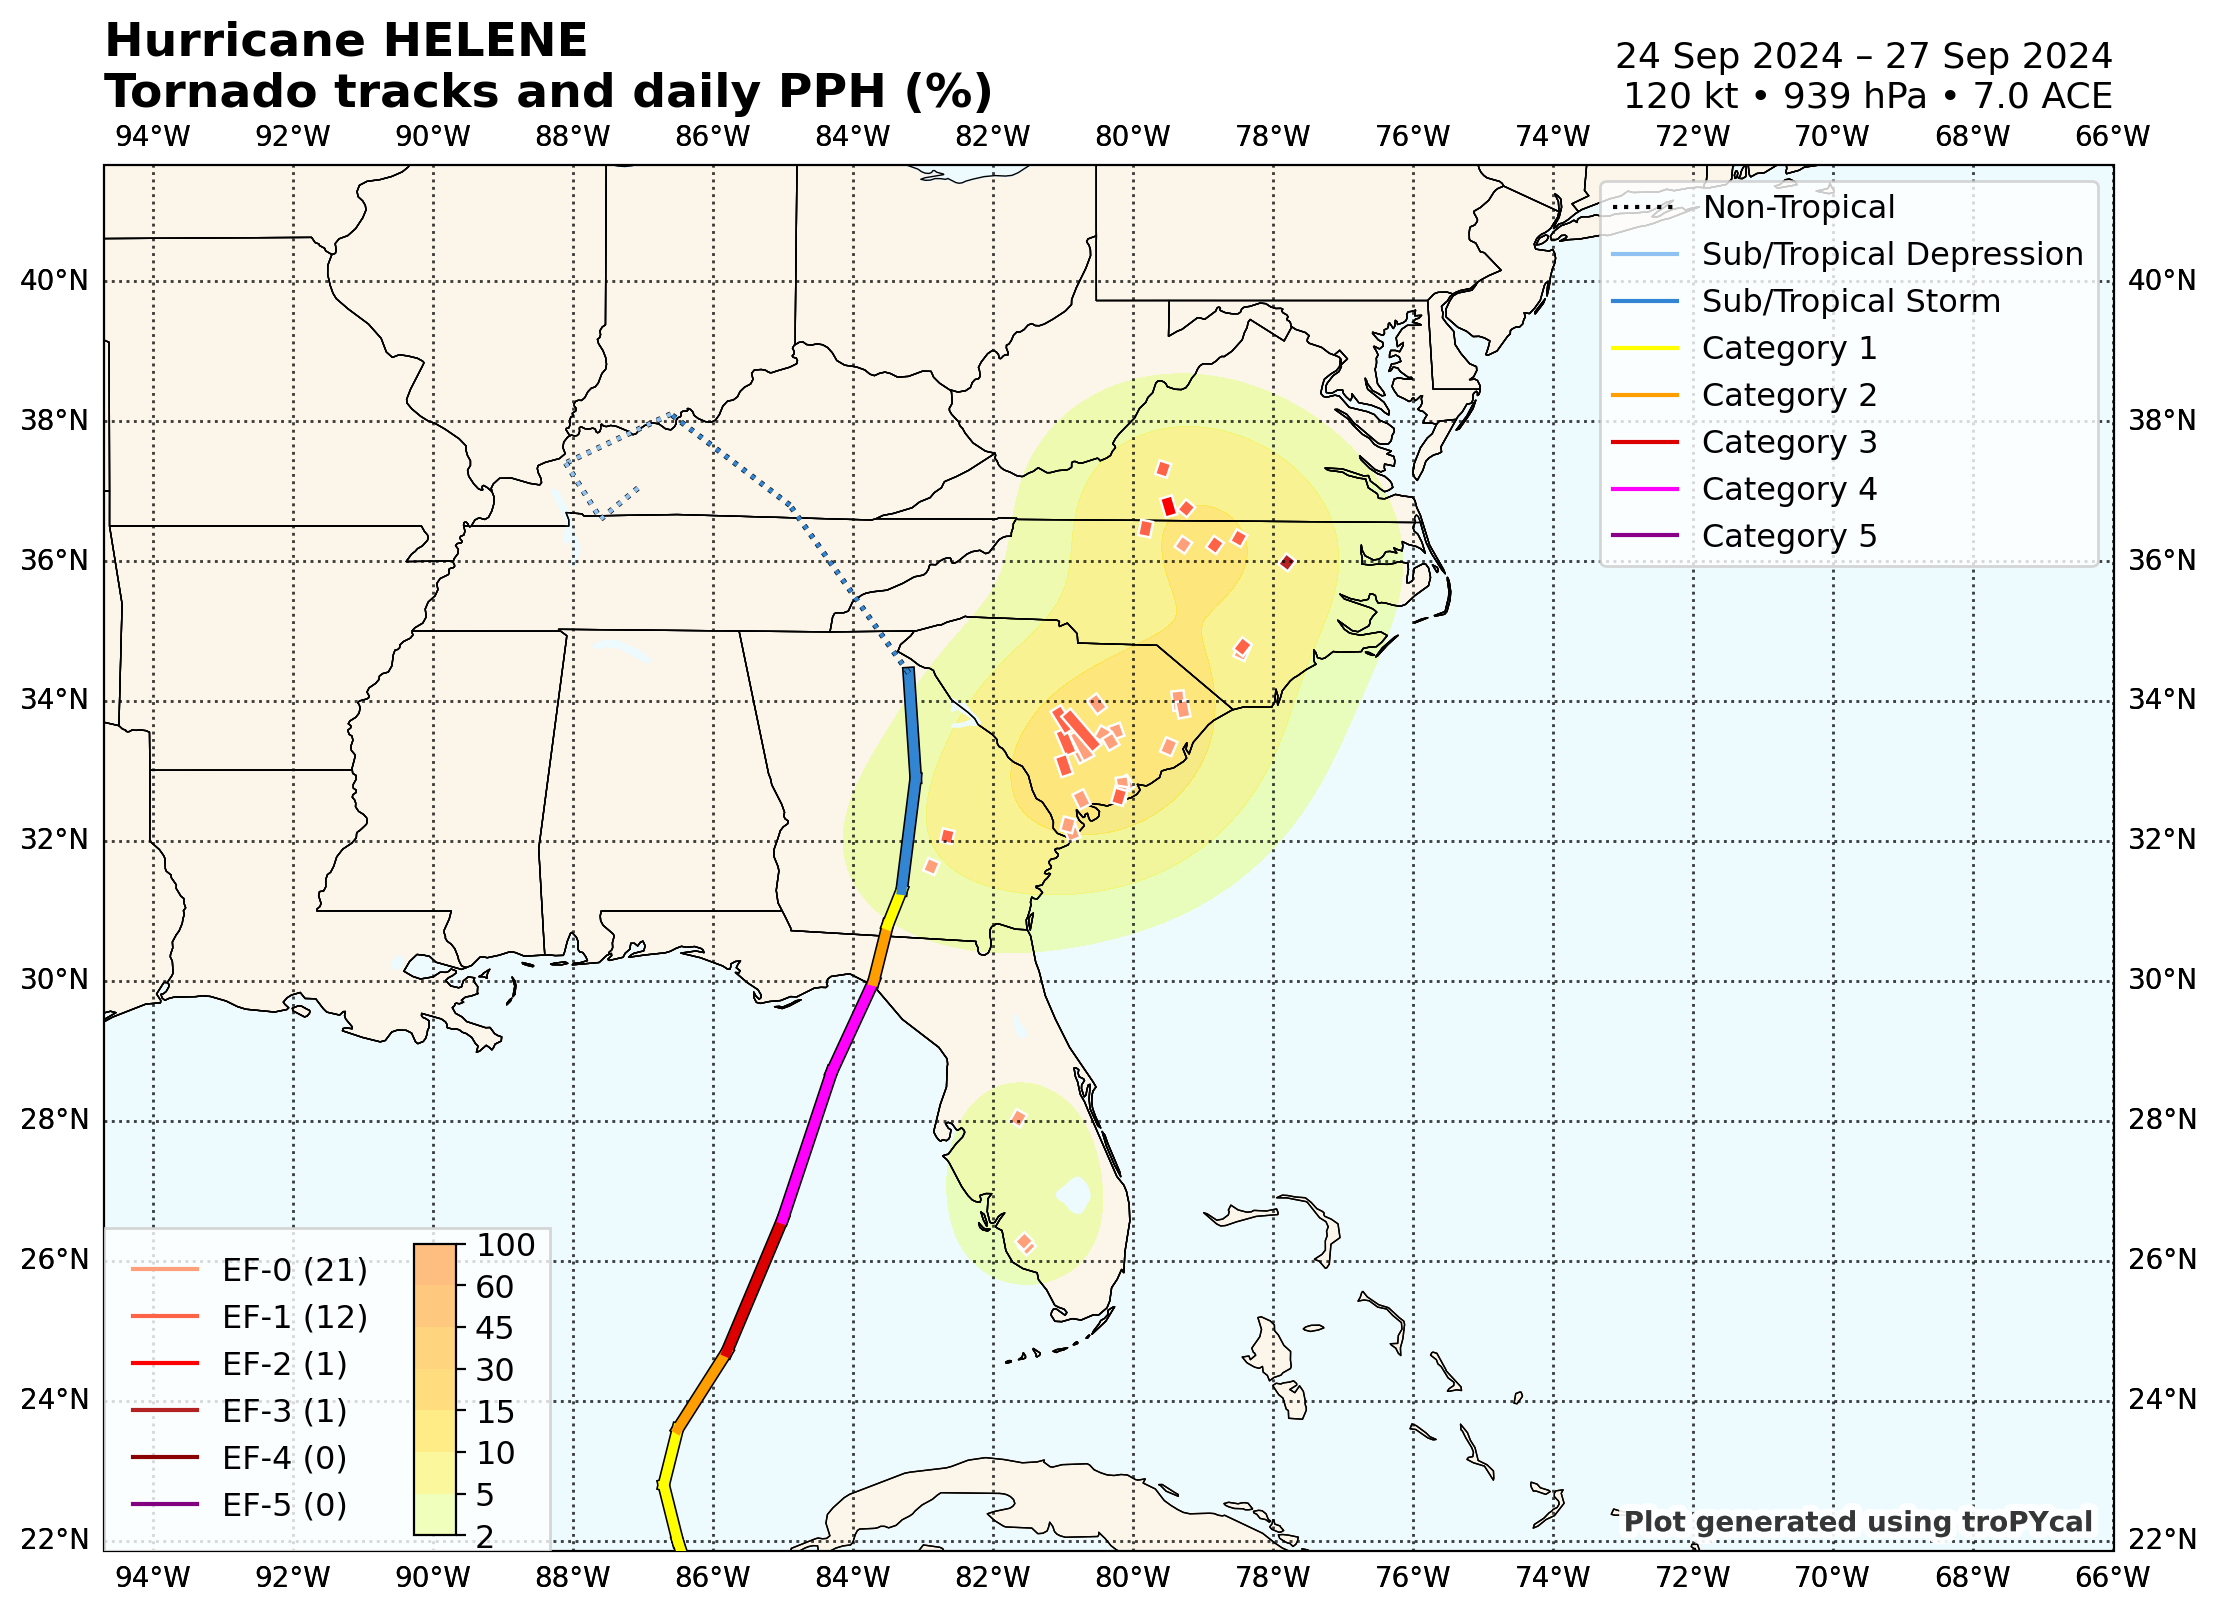

In [14]:
helene.plot_tors(plotPPH=True,prop={'dots':False,'linecolor':'category','linewidth':3.5})

We can also simply plot out the tornado tracks and PPH without the hurricane track if desired, where we can plot out two separate maps of the days when Helene made landfall and continued as a post-tropical system.

(<GeoAxes: title={'left': 'Tornado tracks and daily PPH (%)', 'right': 'Start ... 14:20 UTC 26 Sep 2024\nEnd ... 11:30 UTC 27 Sep 2024'}>,
 {'n': 50.0, 'e': -65.0, 's': 20.0, 'w': -130.0})

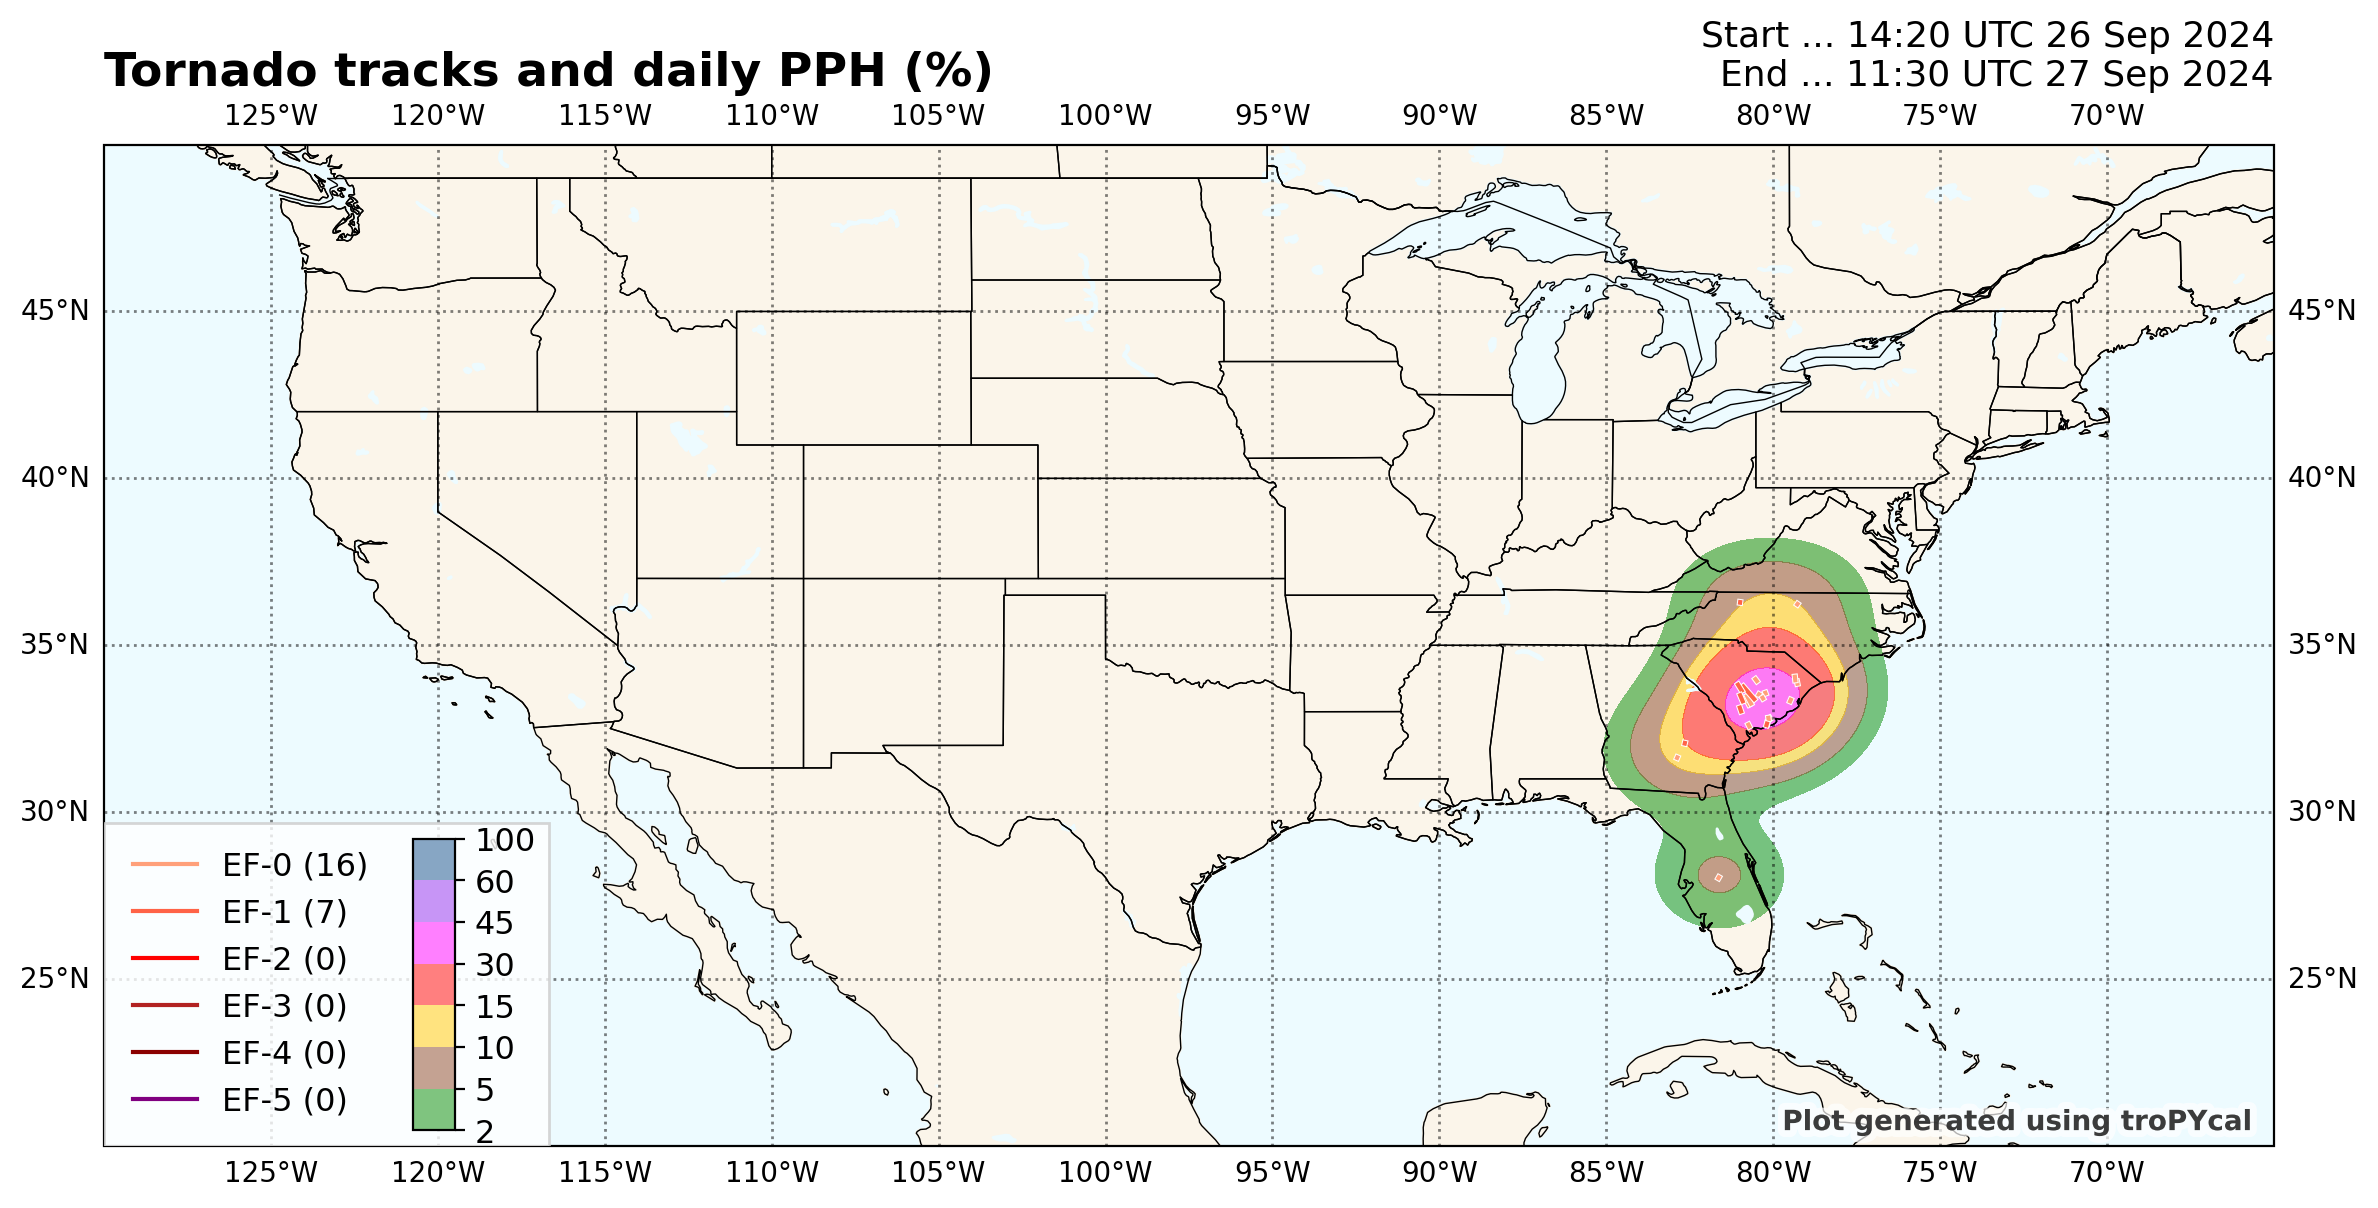

In [15]:
helene_tor_20240926 = tor_ds.plot_tors(dt(2024,9,26),plotPPH=True,return_ax=True)
helene_tor_20240926

(<GeoAxes: title={'left': 'Tornado tracks and daily PPH (%)', 'right': 'Start ... 15:17 UTC 27 Sep 2024\nEnd ... 22:33 UTC 27 Sep 2024'}>,
 {'n': 50.0, 'e': -65.0, 's': 20.0, 'w': -130.0})

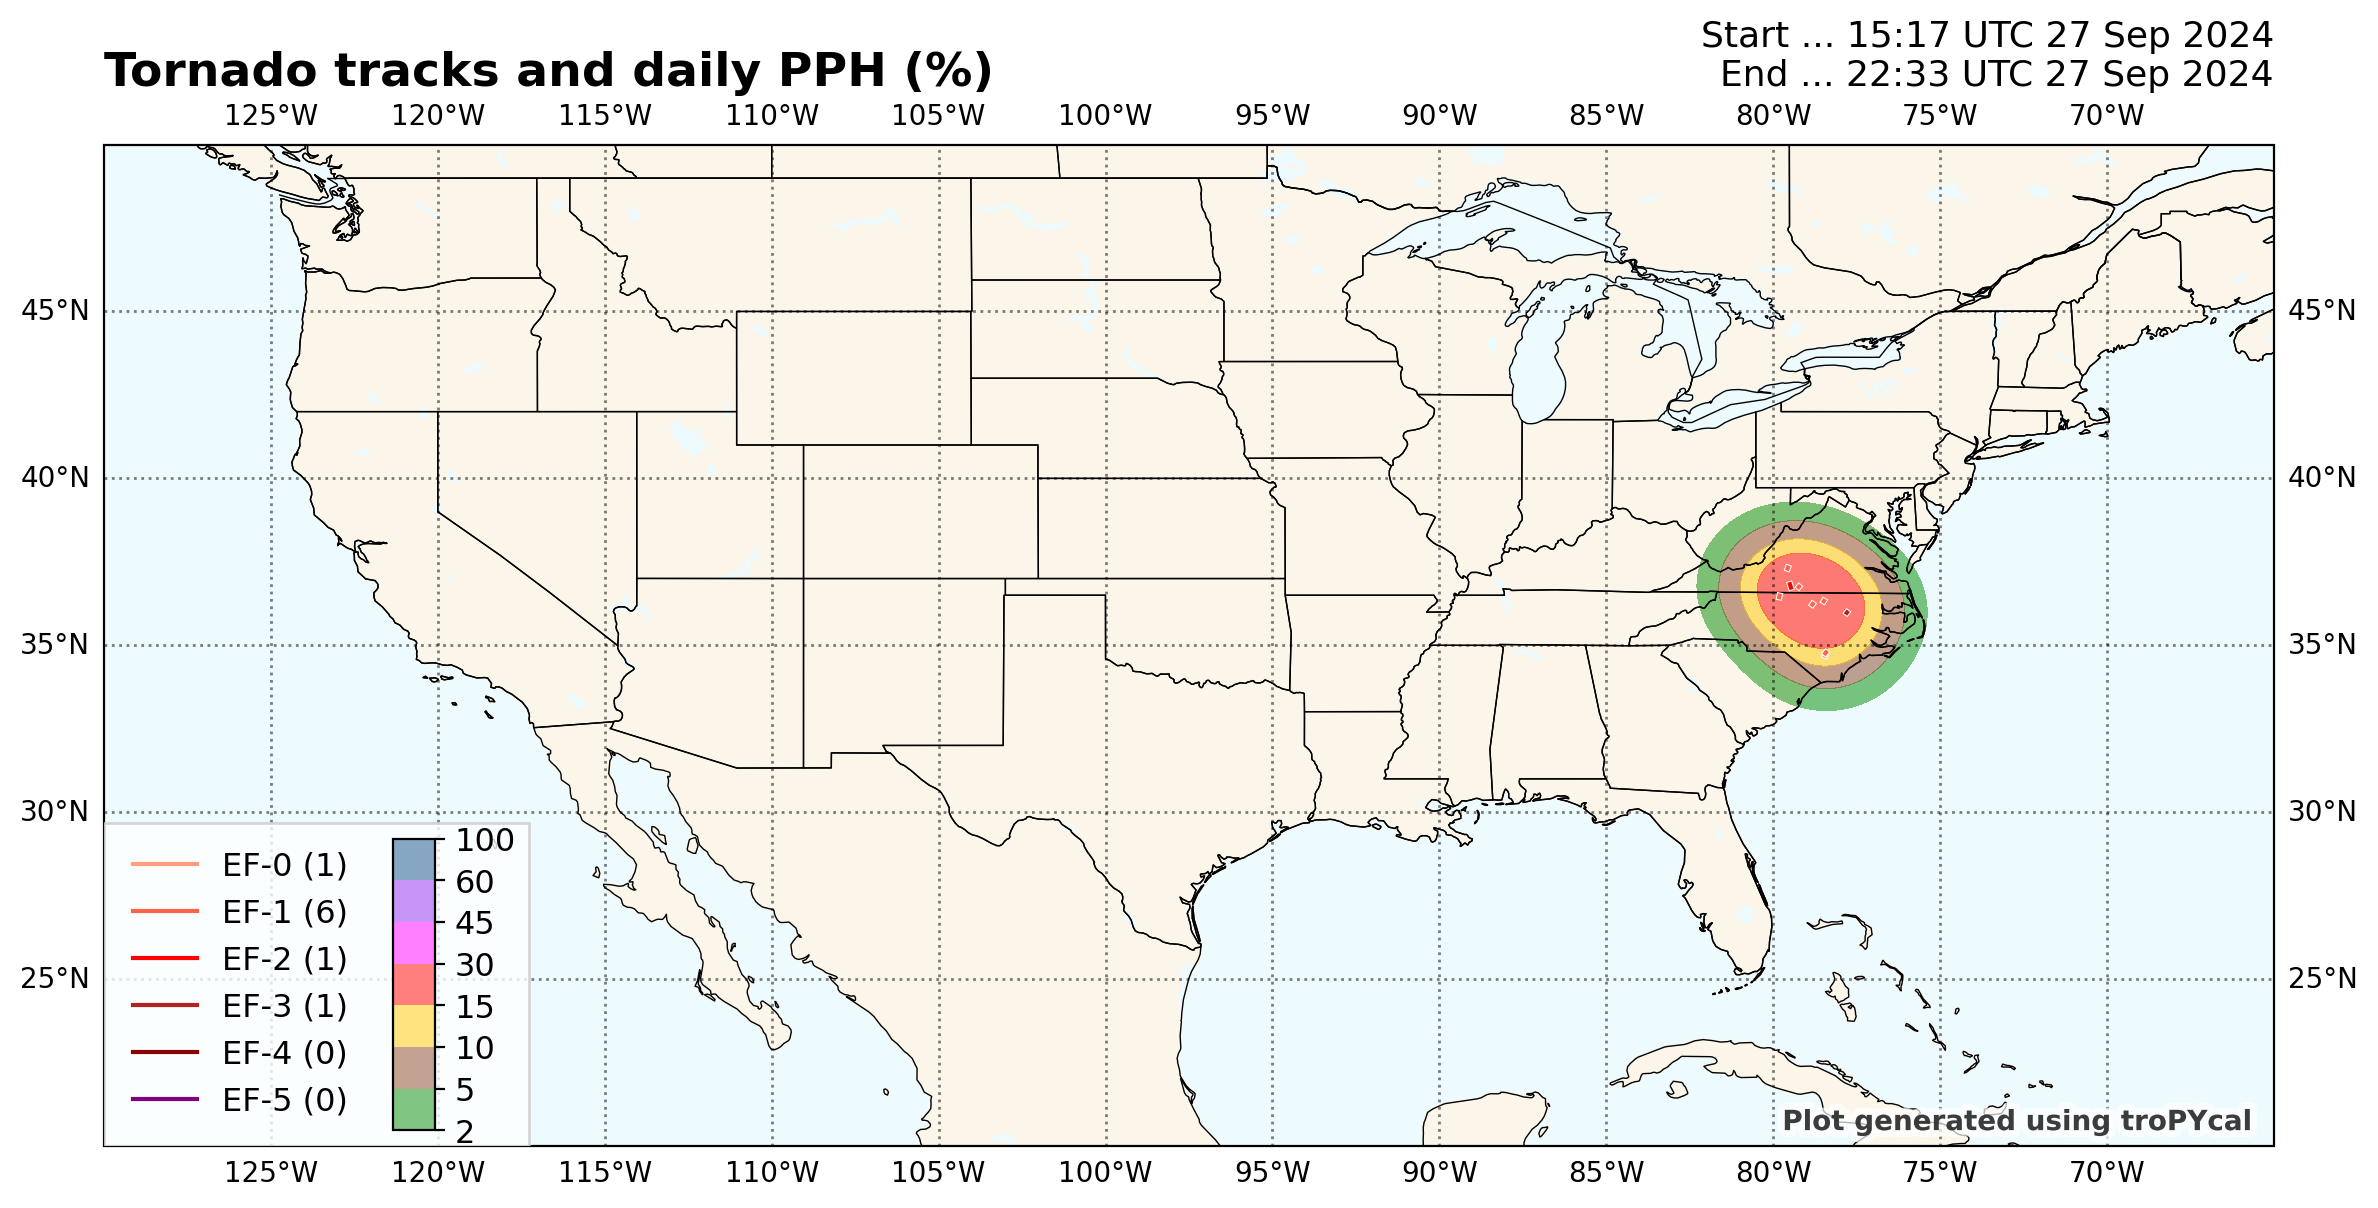

In [16]:
helene_tor_20240927 = tor_ds.plot_tors(dt(2024,9,27),plotPPH=True,return_ax=True)
helene_tor_20240927

For further analysis on tornadoes caused by the hurricane, we can plot the tornado tracks on the quadrants of the storm along with the storm motion.

--> Starting to read in tornado track data
--> Completed reading in tornado data for 1950-2024 (1.15 seconds)


<Axes: title={'center': 'HELENE 2024 tornadoes relative to heading'}, xlabel='Left/Right of Storm Heading (km)', ylabel='Behind/Ahead of Storm Heading (km)'>

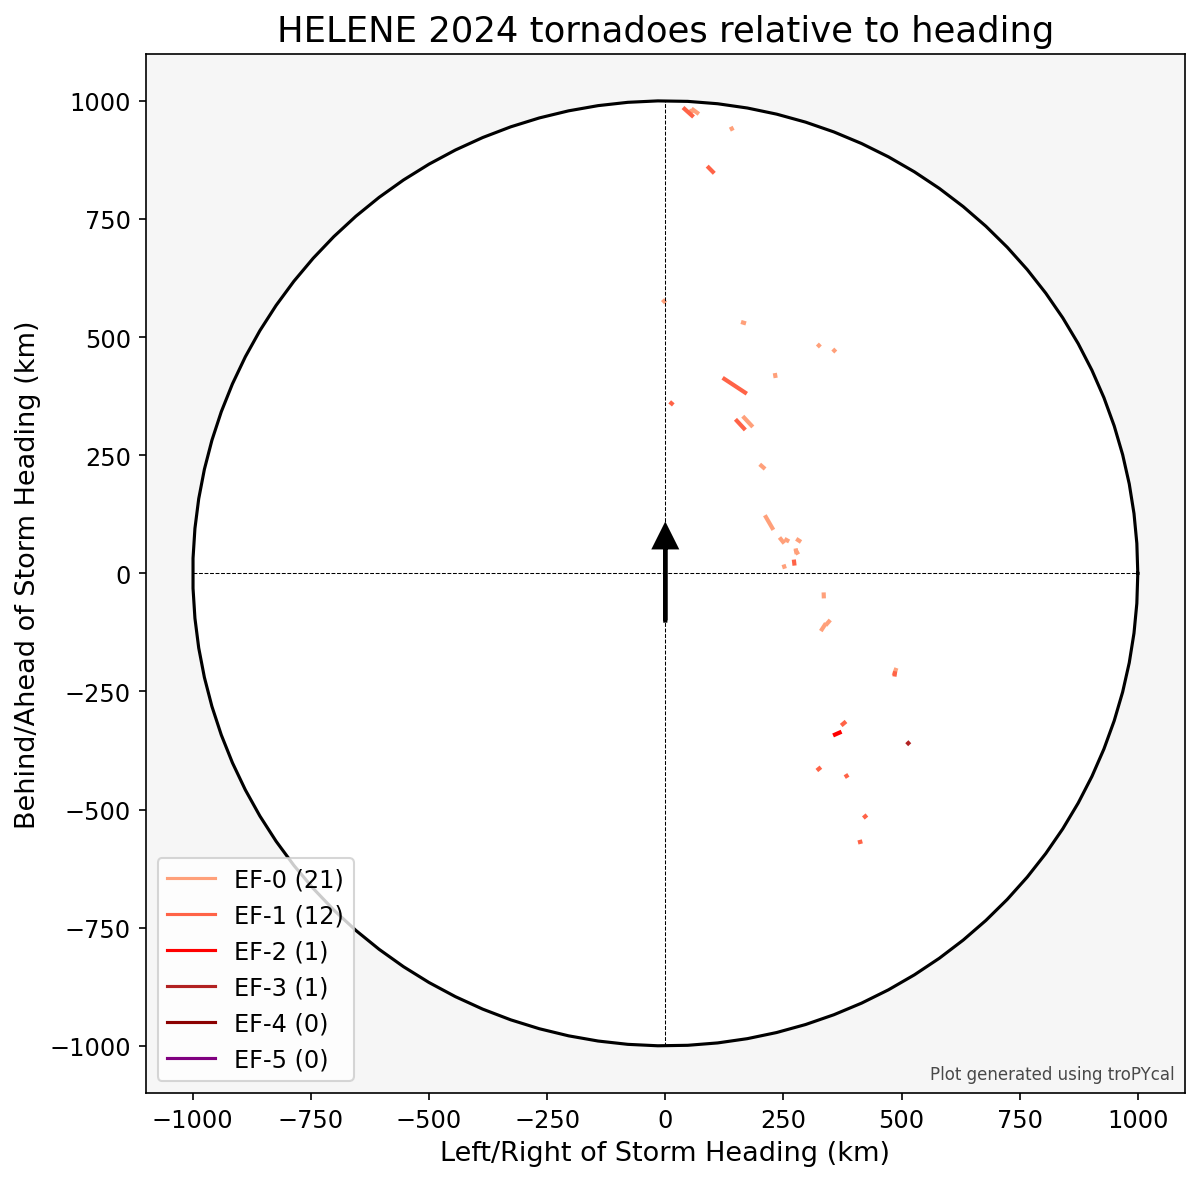

In [17]:
helene.plot_TCtors_rotated()

As we can see with this diagram, as well as the hurricane track and tornado track figure, most, if not all, tornadoes that occurred from Hurricane Helene were in the front and back right (NE & SE) quadrants.

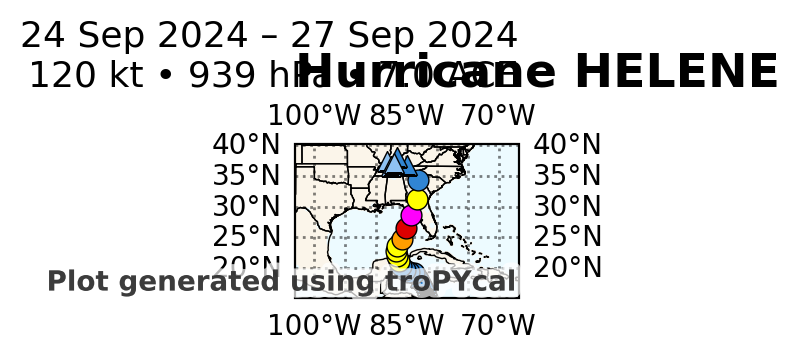

In [22]:
# This is here just to make the thumbnail
helene.plot()

plt.title("")
legend = plt.gca().get_legend()
if legend:
    legend.remove()

dpi = 100
plt.gcf().set_size_inches(150/dpi, 100/dpi)
plt.savefig("thumbnail.png", dpi=dpi, bbox_inches='tight', pad_inches=0)

---

## Summary

Tropycal is a useful tool for analyzing several aspects about tropical cyclones. This includes general information about the storm, such as maximum wind speeds and minimum sea-level pressure values, as well as more unique data, such as tornadoes occurring from the hurricane.

## Resources & References

[Tropycal Website with Source Code](https://tropycal.github.io/tropycal/examples/index.html)